## Cluster-Mass based Permutation testing in Julia

- Step 1: load and check adjacency matrix
- Step 2: generate simuated data
- Step 3: run cluster-mass permutation test

### Load Libraries

In [1]:
import Pkg
#Pkg.activate("/data/p_02865/tools/UnfoldStats.jl/docs")
Pkg.activate("..")
Pkg.instantiate()


using UnfoldSim
using MAT
using CairoMakie
using Random
using Statistics
using UnfoldMixedModels
using UnfoldStats
using DataFrames
using MixedModelsPermutations
using UnfoldMakie
using Logging
using ClusterDepth
using CSV

ext = Base.get_extension(UnfoldStats, :UnfoldStatsMixedModelsPermutationsExt)
lmm_permutations = ext.lmm_permutations
get_lmm_statistic = ext.get_lmm_statistic


include("../read_adjacency.jl")
include("../cluster_mass_test.jl")


  Activating project at `~/Desktop/ClusterComputation`


spatiotemporal_cluster_pvalues (generic function with 1 method)

In [93]:
# 1. Positions CSV
positions_df = CSV.read("channel_positions_Magda.csv", DataFrame;
                     types=[String, Float64, Float64])

# 2.adjacency CSV
adj_df = CSV.read("adjacency_Magda.csv", DataFrame; stringtype=String, strict=false)
electrode_labels = adj_df.Column1
adjacency = select!(adj_df, Not(1))
adjacency = Matrix(adjacency)
adjacency = Bool.(adjacency)

59×59 BitMatrix:
 1  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  1  1  0  0  0
 0  1  0  0  0  0  0  0  0  0  0  0  0     1  0  0  0  0  0  0  1  1  0  0  0
 0  0  1  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  1  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  1  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  1  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  1  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  1  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  1  0  0  0  0     0  0  0  0  0  1  0  0  0  0  0  1
 0  0  0  0  0  0  0  0  0  1  0  0  0     0  0  0  0  0  0  1  0  0  0  0  1
 ⋮              ⋮              ⋮        ⋱           ⋮              ⋮        
 0  0  0  0  0  0  0  0  0  0  0  0  1  …  0  0  0  1  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0 

## Correctly format the EEG data
- **60 subjects** (20 per group)
- **3 time points**
- **3 dependent variables** 1/f, alpha and beta (should all be in seperate data arrays)

In [80]:
electrode_labels

59-element Vector{String}:
 "Fp1"
 "Fp2"
 "F3"
 "F4"
 "C3"
 "C4"
 "P3"
 "P4"
 "O1"
 "O2"
 ⋮
 "TP7"
 "TP8"
 "PO7"
 "PO8"
 "Fpz"
 "AFz"
 "FCz"
 "CPz"
 "POz"

In [134]:
# read the data
#T = Float64
#T = AbstractFloat
#data_alpha = Array{T}(undef, 64, 1, 180)
data_alpha = Array{Union{Missing,Float64}}(undef, 59, 1, 180)

for (i, channel) in enumerate(electrode_labels)
    df_fooof = CSV.read("/Users/mg/Desktop/MOVE/resting_state/fooof/$(channel)_fooof_params.csv", DataFrame)
    alpha_vector = df_fooof.beta_PW_absolute_periodic_log
    #alpha_vector = df_fooof.exponent
    #print(length(alpha_vector))
    data_alpha[i, 1, :] = alpha_vector
end

data_alpha = Float64.(coalesce.(data_alpha, NaN))  # replace "missing" with "nan" so it can be Float64
data_alpha

59×1×180 Array{Float64, 3}:
[:, :, 1] =
 -13.240308977937813
 -13.277087506303545
 -13.005161537935527
 -13.267557487050656
 -12.57075240398084
 -12.797952371276804
 -12.890730492421108
 -12.764830841215344
 -12.326108671041535
 -12.802325376176567
   ⋮
 -12.648901343414975
 -12.87988124607997
 -12.209495597820139
 -12.634401211828987
 -13.193223209554008
 -13.086556972504944
 -12.93947480393179
 -12.965619515752602
 -12.742405071332692

[:, :, 2] =
 -13.115390646527807
 -12.741018598209367
 -12.91092119322191
 -13.175381859306556
 -12.502447521986381
 -12.660308344016574
 -12.825366361744331
 -12.738835581049479
 -12.155216957597865
 -12.73711176531758
   ⋮
 -12.738778405684808
 -12.542391936035594
 -12.039654216539788
 -12.565480819978546
 -13.160362792355079
 -13.073796026597636
 -12.873410656494734
 -12.814570123626506
 -12.672529557265552

[:, :, 3] =
 -12.620312998894958
 -12.513130078395983
 -12.880573828514612
 -12.848274233879698
 -12.651957372992452
 -12.573161964643305
 -13.

In [65]:
# format the dependent variables for the mixed models
df_behavior = CSV.read("/Users/mg/Desktop/MOVE/MOVE_Analysis_MG/KINARM/behavioral_measure.csv", DataFrame)
rename!(df_behavior, :VP => :Subject )
df_evts = select(df_behavior, [:Subject, :Behavior, :Group])
evts = repeat(df_evts, inner = 3)
evts.Time = repeat(1:3, 60)
evts.Subject = string.(evts.Subject)  # Subject needs to be categorical for model
evts

Row,Subject,Behavior,Group,Time
,String,Float64,String1,Int64
1,1,0.0623471,C,1
2,1,0.0623471,C,2
3,1,0.0623471,C,3
4,2,-6.97687,A,1
5,2,-6.97687,A,2
6,2,-6.97687,A,3
7,3,-2.00111,M,1
8,3,-2.00111,M,2
9,3,-2.00111,M,3


In [45]:
# Fit mass-univariate LMM on one time point
println("Fitting LMM at each channel × time point...")
@time m = fit(
    UnfoldModel,
    [
        Any => (
            @formula(0 ~ 1 + stimtype + (1 | item) + (1 | subject)),
            times,
        ),
    ],
    evts,
    data_1t,
);

Fitting LMM at each channel × time point...
  0.009646 seconds (32.35 k allocations: 1.275 MiB)


In [135]:
# Fit mass-univariate LMM
# was ist mit effects coding? (bei meinem mixed model in C3, gebe ich das an!)

times = [1]

# what I want:
println("Fitting LMM at each channel...")
@time m = fit(
    UnfoldModel,
    [
        Any => (
            @formula(0 ~ Group * Time + (1+Time | Subject)),
            times,
        ),
    ],
    evts,
    data_alpha,
);

Fitting LMM at each channel...
  0.088065 seconds (64.91 k allocations: 1.935 MiB)


### 3. Perform cluster-mass permutation test

In [136]:
# --- Cluster-mass permutation test using explicit functions ---

coefficient = 2  # stimtype effect (face vs car)
n_permutations = 50  # Reduced for dev; use 500-1000 for real analyses
threshold = 2.0

time_selection = 1:length(times)

# 2. Generate permutation distribution
permuted = lmm_permutations(MersenneTwister(42), m, data_alpha, coefficient;
    n_permutations = n_permutations,
    lmm_statistic = :z,
    time_selection = time_selection
)



59×1×50 Array{Float64, 3}:
[:, :, 1] =
  0.8568905976340185
  0.9312177390086637
  0.8483673685374274
  0.3231710706537424
  0.21292709735991613
  0.05988768552993225
  0.4755086653923167
  0.4522302405213073
  0.44469290121760563
 -0.15099469566044477
  ⋮
  1.0205001559069684
  0.32440098618281193
  0.7263684700018921
  0.3151891162043689
  0.12986658476040447
  0.5390927364394404
 -0.055519554479681085
  0.6994581413427102
  0.676619225675257

[:, :, 2] =
 -0.6384617434177982
  0.0071363659983319965
 -0.3382904694936256
 -0.07542611164270413
 -1.1515416676076975
 -0.9377119662767432
 -0.48030658044463886
 -0.5728193815653535
 -0.01130988433318974
 -0.5727887627978271
  ⋮
 -0.7916291263449795
  0.008358803619812036
  0.009379664010508595
 -0.6303679410522389
  0.5751976270065523
  0.1608079525846448
 -0.4764818581023659
  0.05471240727226052
 -0.24400972480484887

[:, :, 3] =
 -0.09279635878119091
 -0.28378662195514687
 -0.37877550572637003
 -0.16811317465598613
 -0.8756568616693591
 

In [124]:
coefs = coeftable(m)
unique(coefs.coefname)

6-element Vector{String}:
 "(Intercept)"
 "Group: C"
 "Group: M"
 "Time"
 "Group: C & Time"
 "Group: M & Time"

Available columns: ["channel", "coefname", "estimate", "eventname", "group", "stderror", "time"]
Rows for stimtype: 118
Unique channels: 59
Unique times: 1

=== Uncorrected Effects (before permutation) ===
Max |z|: 3.28
Peak location: channel C1 at t = 1.0s
Samples with |z| > 2.0: 15 / 59
Samples with |z| > 1.96: 15 (uncorrected p < 0.05)


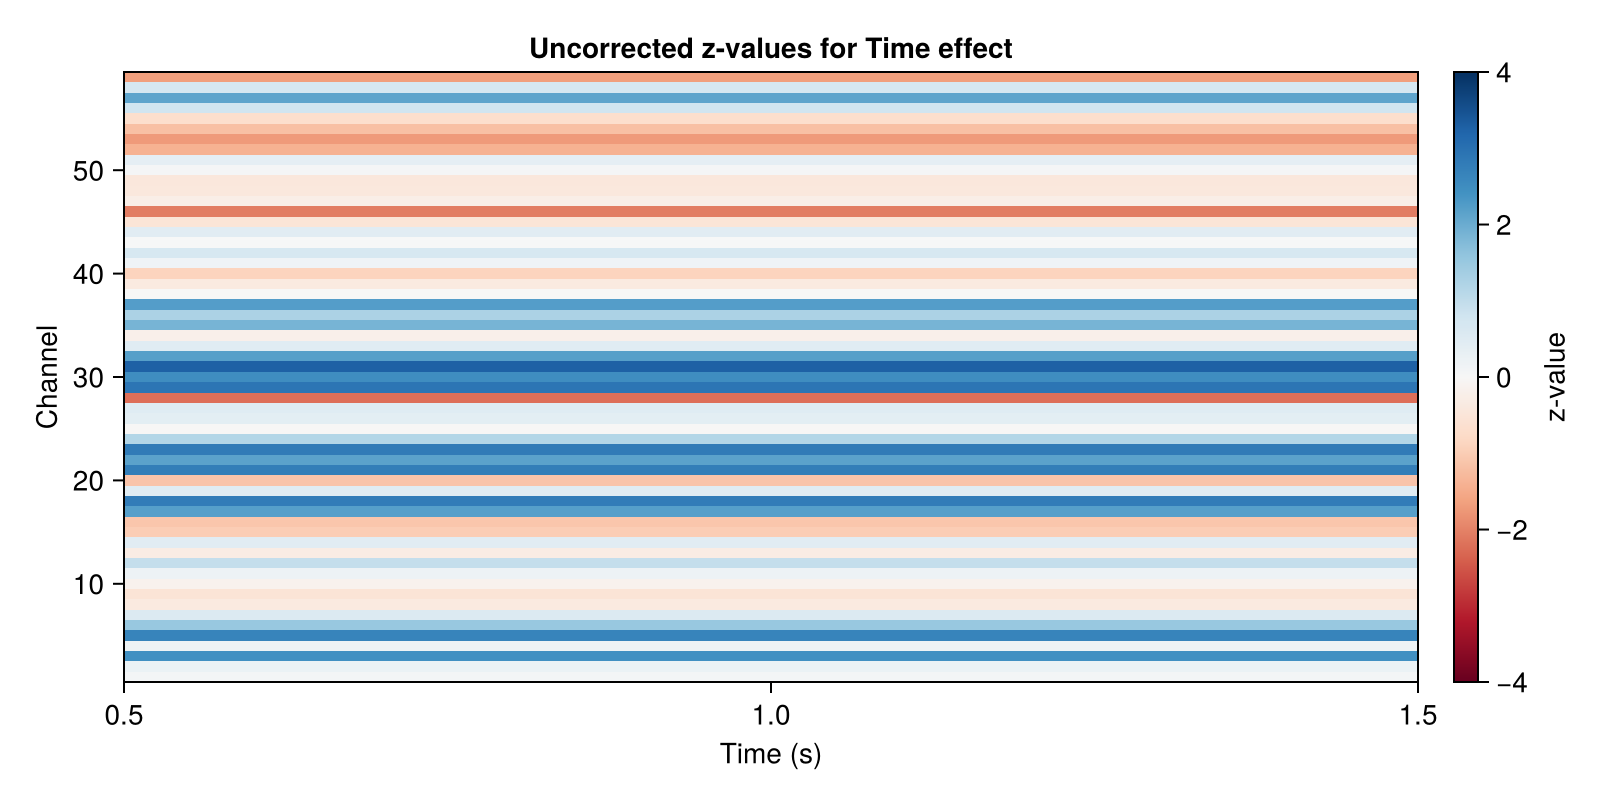

In [137]:
# Check uncorrected effects before running permutation test
# Extract coefficients for the stimtype effect
coefs = coeftable(m)

# Show available columns
println("Available columns: $(names(coefs))")
#println(r.coefname)

# Filter for stimtype coefficient
coef_stimtype = filter(r -> r.coefname == "Time", coefs)
println("Rows for stimtype: $(nrow(coef_stimtype))")

# Check how many unique channels and times we have
unique_channels = sort(unique(coef_stimtype.channel))
unique_times = sort(unique(coef_stimtype.time))
println("Unique channels: $(length(unique_channels))")
println("Unique times: $(length(unique_times))")

# Compute z-values from estimate/stderror, handling missing values
# Replace Nothing with NaN for computation
estimate_vec = [isnothing(x) ? NaN : Float64(x) for x in coef_stimtype.estimate]
stderror_vec = [isnothing(x) ? NaN : Float64(x) for x in coef_stimtype.stderror]
z_vec = estimate_vec ./ stderror_vec

coef_stimtype[!, :z] = z_vec

# Average across groups if there are multiple entries per channel×time
z_summary = combine(
    groupby(coef_stimtype, [:channel, :time]),
    :z => (x -> mean(filter(!isnan, x))) => :z
)
sort!(z_summary, [:channel, :time])

# Replace NaN with 0 for visualization
z_summary.z = replace(z_summary.z, NaN => 0.0)

# Reshape z-values to channels × times
n_ch_coef = length(unique_channels)
n_t_coef = length(unique_times)
z_vals = reshape(z_summary.z, n_t_coef, n_ch_coef)'  # (channels × times)

# Check for significant z-values (|z| > 2.0)
n_sig_uncorrected = sum(abs.(z_vals) .> 2.0)
max_z = maximum(abs.(z_vals))
peak_idx = argmax(abs.(z_vals))
peak_ch, peak_t = Tuple(CartesianIndices(z_vals)[peak_idx])

println("\n=== Uncorrected Effects (before permutation) ===")
println("Max |z|: $(round(max_z, digits=2))")
println("Peak location: channel $(electrode_labels[peak_ch]) at t = $(round(unique_times[peak_t], digits=3))s")
println("Samples with |z| > 2.0: $(n_sig_uncorrected) / $(length(z_vals))")
println("Samples with |z| > 1.96: $(sum(abs.(z_vals) .> 1.96)) (uncorrected p < 0.05)")

# Quick visualization of z-values
fig_z = Figure(size = (800, 400))
ax_z = Axis(fig_z[1, 1],
    title = "Uncorrected z-values for Time effect",
    xlabel = "Time (s)",
    ylabel = "Channel")
hm = heatmap!(ax_z, collect(unique_times), 1:n_ch_coef, z_vals', colormap = :RdBu, colorrange = (-4, 4))
Colorbar(fig_z[1, 2], hm, label = "z-value")
fig_z

In [57]:
electrode_labels

32-element Vector{String}:
 "Fp1"
 "AF3"
 "F7"
 "F3"
 "FC1"
 "FC5"
 "T7"
 "C3"
 "CP1"
 "CP5"
 ⋮
 "T8"
 "FC6"
 "FC2"
 "F4"
 "F8"
 "AF4"
 "Fp2"
 "Fz"
 "Cz"

In [94]:
adjacency

59×59 BitMatrix:
 1  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  1  1  0  0  0
 0  1  0  0  0  0  0  0  0  0  0  0  0     1  0  0  0  0  0  0  1  1  0  0  0
 0  0  1  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  1  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  1  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  1  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  1  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  1  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  1  0  0  0  0     0  0  0  0  0  1  0  0  0  0  0  1
 0  0  0  0  0  0  0  0  0  1  0  0  0     0  0  0  0  0  0  1  0  0  0  0  1
 ⋮              ⋮              ⋮        ⋱           ⋮              ⋮        
 0  0  0  0  0  0  0  0  0  0  0  0  1  …  0  0  0  1  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0 

Significant cluster IDs: [1]


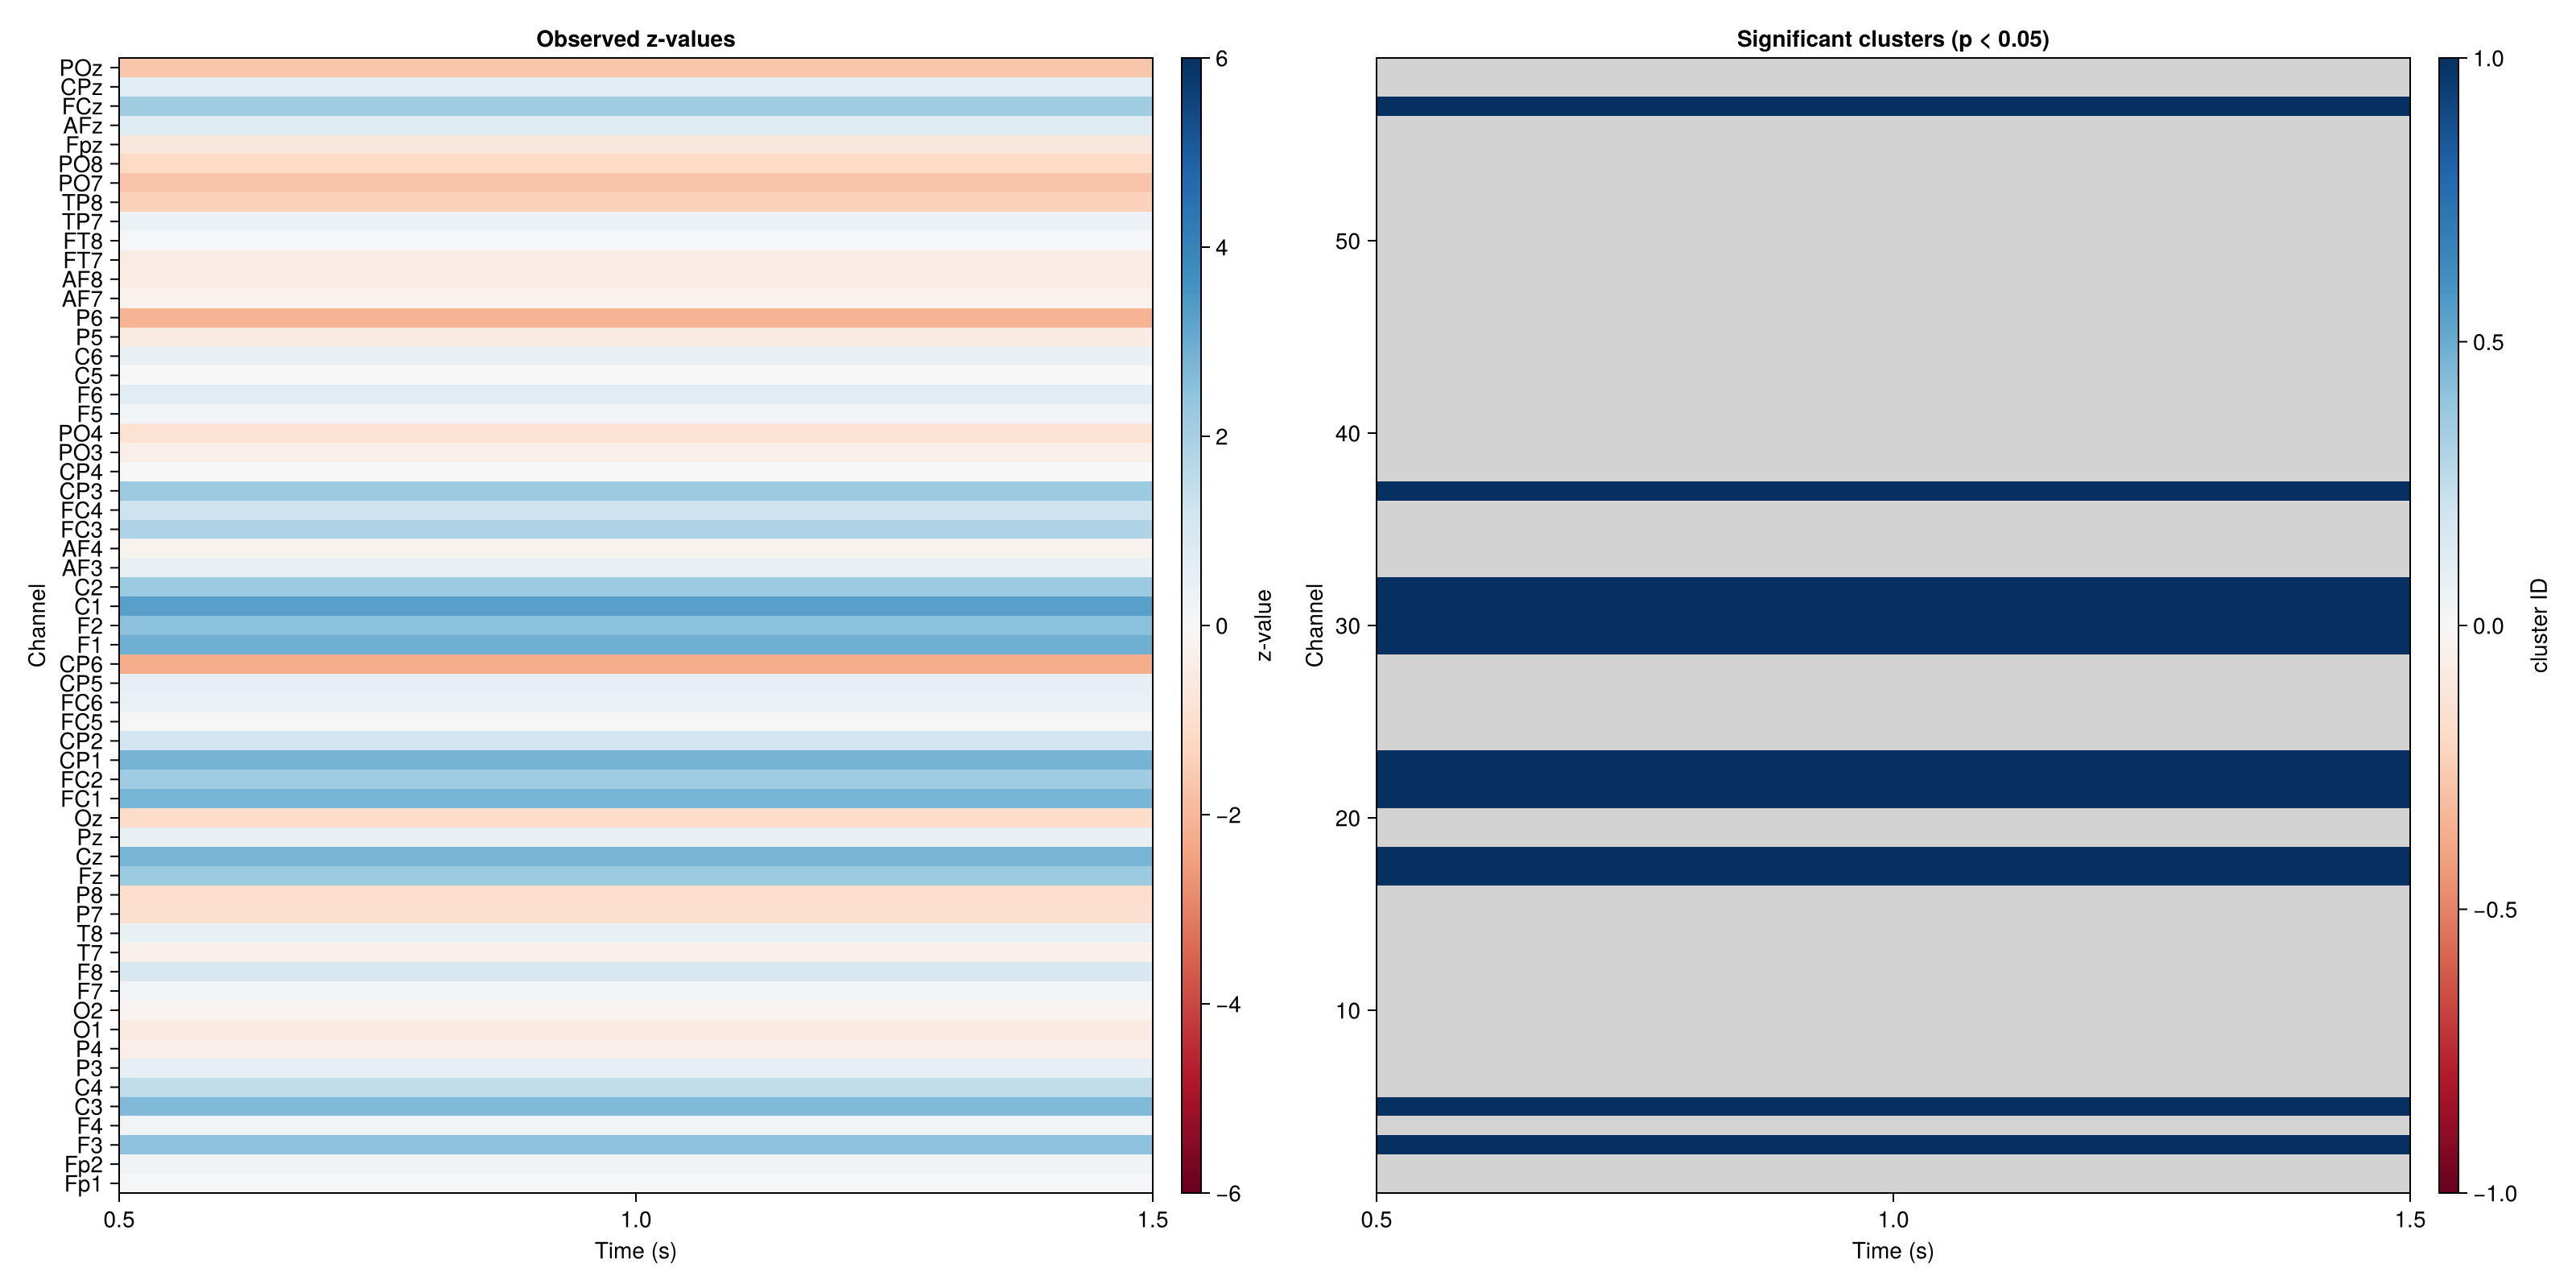

In [138]:
# 3. Run cluster-mass permutation test
n_channels = 59

observed = z_vals
pvals_clustermass, cluster_ids = spatiotemporal_cluster_pvalues(MersenneTwister(1), observed, permuted, adjacency, threshold)

# Only show significant clusters (p < 0.05); everything else → NaN (lightgray)
cluster_display = Float64.(cluster_ids)
cluster_display[(pvals_clustermass .>= 0.05) .| (cluster_ids .== 0)] .= NaN

sig_ids = sort(unique(cluster_ids[pvals_clustermass .< 0.05]))
println("Significant cluster IDs: $sig_ids")

n_clusters = maximum(abs.(cluster_ids))
crange = n_clusters == 0 ? (-1.0, 1.0) : (-Float64(n_clusters), Float64(n_clusters))

# 4. Visualize
fig = Figure(size = (1600, 800))

# Panel 1: Observed z-values with threshold contours
ax1 = Axis(fig[1, 1], title = "Observed z-values", xlabel = "Time (s)", ylabel = "Channel",
           yticks = (1:n_channels, electrode_labels))
hm1 = heatmap!(ax1, collect(times), 1:n_channels, z_vals', colormap = :RdBu, colorrange = (-6, 6))
Colorbar(fig[1, 2], hm1, label = "z-value")
contour!(ax1, collect(times), 1:n_channels, z_vals', levels = [threshold],  color = (:red,  0.7), linewidth = 1.5)
contour!(ax1, collect(times), 1:n_channels, z_vals', levels = [-threshold], color = (:blue, 0.7), linewidth = 1.5)

# Panel 2: Significant cluster labels only (warm = positive, cool = negative, gray = non-sig / no cluster)
ax2 = Axis(fig[1, 3], title = "Significant clusters (p < 0.05)",
           xlabel = "Time (s)", ylabel = "Channel")
hm2 = heatmap!(ax2, collect(times), 1:n_channels, cluster_display',
               colormap = :RdBu, colorrange = crange, nan_color = :lightgray)
Colorbar(fig[1, 4], hm2, label = "cluster ID")

fig

In [139]:
pvals_clustermass .< 0.05

59×1 BitMatrix:
 0
 0
 1
 0
 1
 0
 0
 0
 0
 0
 ⋮
 0
 0
 0
 0
 0
 0
 1
 0
 0

In [140]:
# create topoplot and butterfly plot for selected channels only
pos3d = hart.electrodes["pos"][channel_idx, :]  # 32x3 matrix for selected channels
pos2d = [Point2f(pos3d[i,1], pos3d[i,2]) for i in 1:size(pos3d,1)]  # convert to 2D points for topoplot
sig_mask = pvals_clustermass .< 0.05
cluster_data = copy(z_vals)
#cluster_data[.!sig_mask] .= 0.0  # Set non-significant to zero (or NaN)
# Ensure correct orientation: time x channels
df = DataFrame(
    :estimate => vec(cluster_data),  # no transpose, time is slow axis, channels is fast axis
    :channel => repeat(1:size(cluster_data, 1), outer = size(cluster_data, 2)),
    :time => repeat(1:size(cluster_data, 2), inner = size(cluster_data, 1))
)

UndefVarError: UndefVarError: `hart` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

Averaging across 1 time points
Any NaN in avg_topo: false


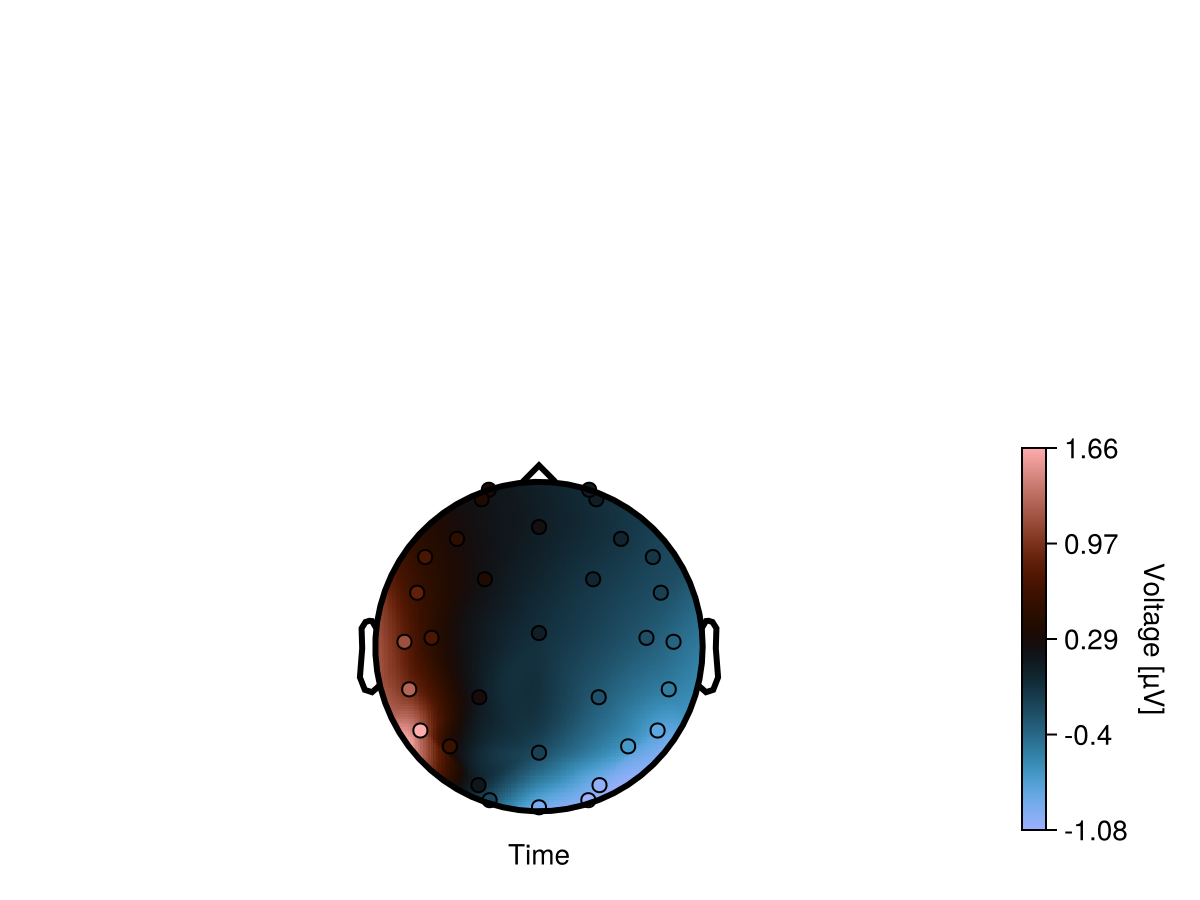

In [53]:
f = Figure()
# Average ERP across all trials for each channel and time
erp = mean(data_1t; dims=3)[:,:,1]  # (channels x times)
df_erp = DataFrame(
    :amplitude => vec(erp),
    :channel => repeat(1:size(erp, 1), outer = size(erp, 2)),
    :time => repeat(1:size(erp, 2), inner = size(erp, 1))
)
#plot_butterfly!(f[1, 1:2], df_erp; positions = pos2d, mapping=(; y=:amplitude))
# Find significant time points (p < 0.05)
# sig_mask is channels x times, so get time indices where any channel is significant
sig_time_bool = vec(any(sig_mask, dims=1))
unique_times = sort(unique(df_erp.time))
sig_times = unique_times[sig_time_bool]
if isempty(sig_times)
    @warn "No significant time points found; falling back to averaging across all times"
    sig_times = unique_times
end
println("Averaging across $(length(sig_times)) time points")
# Compute average topography robustly (avoid averaging over empty selection)
avg_topo = Float64[]
for ch in 1:n_channels
    sel = (df_erp.channel .== ch) .& in.(df_erp.time, Ref(sig_times))
    vals = df_erp.amplitude[sel]
    if isempty(vals)
        push!(avg_topo, NaN)
    else
        push!(avg_topo, mean(vals))
    end
end
println("Any NaN in avg_topo: ", any(isnan, avg_topo))
if any(isnan, avg_topo)
    @warn "avg_topo contains NaNs for channels: $(findall(isnan, avg_topo))"
end
# Highlight significant channels: a channel is significant if any time point is significant for it
sig_ch = [any(sig_mask[ch, :]) for ch in 1:n_channels]
# Set marker color: red for significant, gray for others
marker_colors = [is_sig ? :white : :gray for is_sig in sig_ch]
# Set marker size: larger for significant, smaller for others
marker_sizes = [is_sig ? 10 : 10 for is_sig in sig_ch]
plot_topoplot!(
    f[2, 1],
    DataFrame(:amplitude => avg_topo, :channel => 1:n_channels);
    positions = pos2d,
    mapping=(; y=:amplitude),
    visual = (; enlarge = 1, label_scatter = true, colormap = :berlin, contours = false),
    colorrange = (; colorrange = (-0.5, 0.5)),
    topo_attributes = (; label_scatter = (; color = marker_colors, markersize = marker_sizes)),
    )

f